In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

load_dotenv()
password = quote_plus(os.getenv('DB_PASSWORD'))
DB_URL = f"postgresql://{os.getenv('DB_USER')}:{password}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(DB_URL)
print("  Connected! Starting Machine Learning...")

  Connected! Starting Machine Learning...


In [16]:
query = """
WITH customer_metrics AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id)       AS frequency,
        SUM(oi.price)                    AS monetary,
        MAX(o.order_purchase_timestamp)  AS last_order_date
    FROM customers c
    JOIN orders o       ON c.customer_id  = o.customer_id
    JOIN order_items oi ON o.order_id    = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)
SELECT
    customer_unique_id,
    frequency,
    ROUND(monetary::numeric, 2) AS monetary,
    EXTRACT(DAY FROM (
        '2018-10-01'::timestamp - last_order_date
    )) AS recency_days
FROM customer_metrics;
"""
df_rfm = pd.read_sql(query, engine)
print(f"  RFM data loaded: {len(df_rfm):,} customers")
print(df_rfm.describe().round(2))

  RFM data loaded: 93,358 customers
       frequency  monetary  recency_days
count   93358.00  93358.00      93358.00
mean        1.03    141.62        269.48
std         0.21    215.69        152.60
min         1.00      0.85         32.00
25%         1.00     47.65        146.00
50%         1.00     89.73        250.00
75%         1.00    154.74        378.00
max        15.00  13440.00        745.00


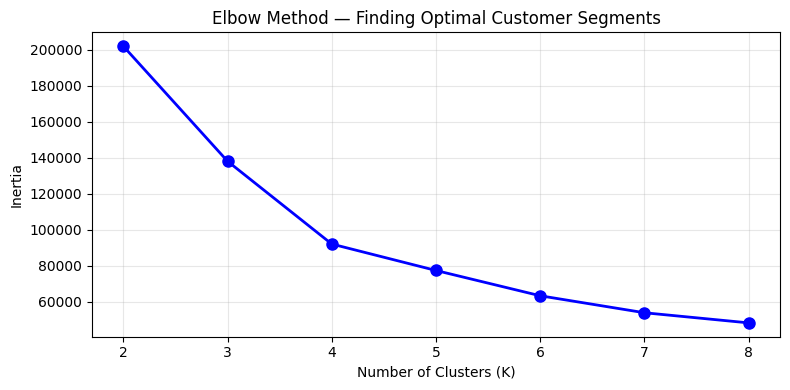

Look for where the curve bends — that's our best K!


In [15]:
features = ['recency_days', 'frequency', 'monetary']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_rfm[features])

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal Customer Segments')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dashboards/elbow_curve.png', dpi=150)
plt.show()
print("Look for where the curve bends — that's our best K!")

In [5]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_rfm['segment'] = km.fit_predict(X_scaled)

segment_summary = df_rfm.groupby('segment').agg(
    customers     = ('customer_unique_id', 'count'),
    avg_recency   = ('recency_days', 'mean'),
    avg_frequency = ('frequency', 'mean'),
    avg_monetary  = ('monetary', 'mean')
).round(2)

print("=== Customer Segment Summary ===")
print(segment_summary.to_string())

=== Customer Segment Summary ===
         customers  avg_recency  avg_frequency  avg_monetary
segment                                                     
0             2188       269.22           1.01       1142.24
1            37566       419.17           1.00        114.09
2             2774       251.94           2.11        243.16
3            50830       159.82           1.00        113.36


In [6]:
# Name each segment based on their RFM characteristics
segment_names = {}
for seg in range(4):
    r = segment_summary.loc[seg, 'avg_recency']
    m = segment_summary.loc[seg, 'avg_monetary']
    f = segment_summary.loc[seg, 'avg_frequency']
    
    if m > df_rfm['monetary'].mean() and r < df_rfm['recency_days'].mean():
        segment_names[seg] = 'Champions'
    elif r < df_rfm['recency_days'].mean():
        segment_names[seg] = 'Loyal Customers'
    elif m > df_rfm['monetary'].mean():
        segment_names[seg] = 'Big Spenders'
    else:
        segment_names[seg] = 'At Risk'

df_rfm['segment_name'] = df_rfm['segment'].map(segment_names)

print("\n=== Segment Names & Sizes ===")
print(df_rfm['segment_name'].value_counts())
print("\n=== Segment Business Profiles ===")
print(df_rfm.groupby('segment_name')[['recency_days','frequency','monetary']].mean().round(2).to_string())


=== Segment Names & Sizes ===
segment_name
Loyal Customers    50830
At Risk            37566
Champions           4962
Name: count, dtype: int64

=== Segment Business Profiles ===
                 recency_days  frequency  monetary
segment_name                                      
At Risk                419.17       1.00    114.09
Champions              259.56       1.63    639.61
Loyal Customers        159.82       1.00    113.36


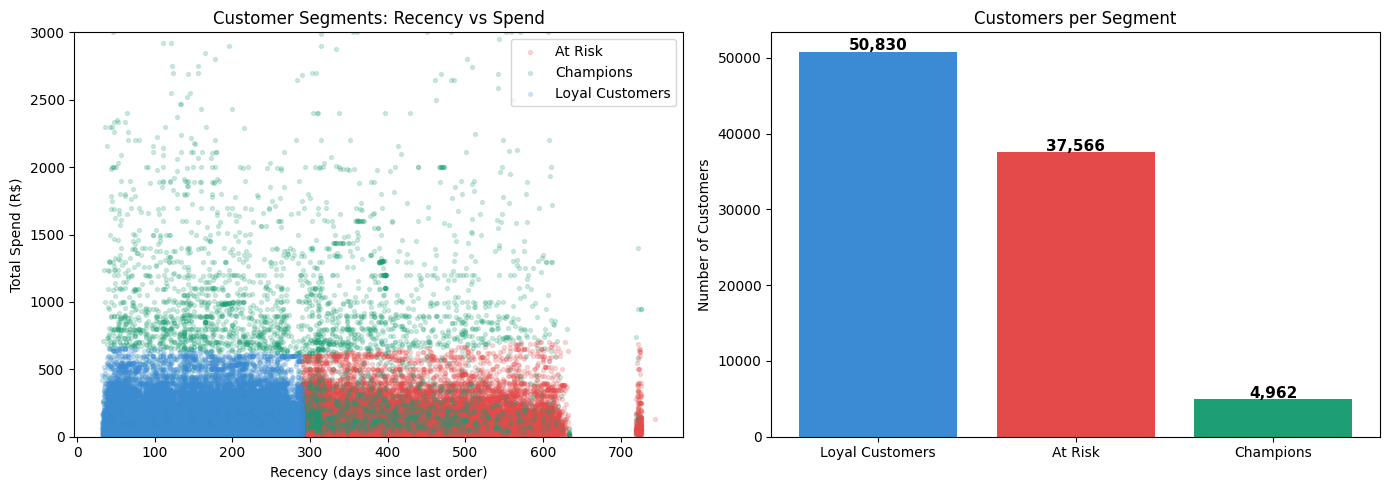

Segmentation chart saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Champions': '#1D9E75', 'Loyal Customers': '#3B8BD4',
          'Big Spenders': '#BA7517', 'At Risk': '#E24B4A'}

# Chart 1 — Scatter: recency vs spend coloured by segment
for name, group in df_rfm.groupby('segment_name'):
    axes[0].scatter(group['recency_days'], group['monetary'],
                    alpha=0.2, c=colors[name], label=name, s=8)
axes[0].set_xlabel('Recency (days since last order)')
axes[0].set_ylabel('Total Spend (R$)')
axes[0].set_title('Customer Segments: Recency vs Spend')
axes[0].legend()
axes[0].set_ylim(0, 3000)

# Chart 2 — Segment sizes bar chart
seg_counts = df_rfm['segment_name'].value_counts()
bar_colors = [colors[s] for s in seg_counts.index]
axes[1].bar(seg_counts.index, seg_counts.values, color=bar_colors)
axes[1].set_title('Customers per Segment')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(seg_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('dashboards/customer_segments.png', dpi=150)
plt.show()
print("Segmentation chart saved!")

In [8]:
# Define churn: customer not seen in last 180 days = churned
df_rfm['churned'] = (df_rfm['recency_days'] > 180).astype(int)

print(f"Churned customers:  {df_rfm['churned'].sum():,} ({df_rfm['churned'].mean()*100:.1f}%)")
print(f"Active customers:   {(df_rfm['churned']==0).sum():,} ({(df_rfm['churned']==0).mean()*100:.1f}%)")

# Features and target
X = df_rfm[['recency_days', 'frequency', 'monetary']]
y = df_rfm['churned']

# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(random_state=42)
model.fit(X_train_s, y_train)

# Evaluate
y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]
auc    = roc_auc_score(y_test, y_prob)

print(f"\n=== CHURN PREDICTION MODEL ===")
print(f"ROC-AUC Score: {auc:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

Churned customers:  62,164 (66.6%)
Active customers:   31,194 (33.4%)

=== CHURN PREDICTION MODEL ===
ROC-AUC Score: 1.000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6206
           1       1.00      1.00      1.00     12466

    accuracy                           1.00     18672
   macro avg       1.00      1.00      1.00     18672
weighted avg       1.00      1.00      1.00     18672



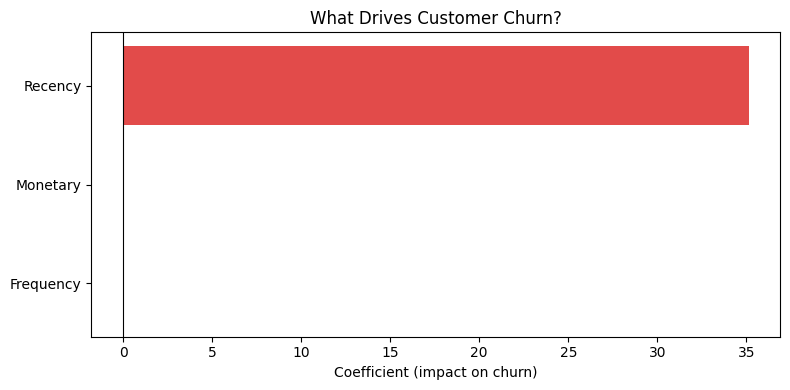

   Phase 6 complete!
   K-Means: 4 customer segments identified
   Churn model: ROC-AUC = 1.000
   Charts saved to dashboards/


In [12]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': ['Recency', 'Frequency', 'Monetary'],
    'coefficient': model.coef_[0]
})
feature_importance['abs_coef'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coef', ascending=True)

plt.figure(figsize=(8, 4))
colors_fi = ['#E24B4A' if c > 0 else '#1D9E75' for c in feature_importance['coefficient']]
plt.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors_fi)
plt.xlabel('Coefficient (impact on churn)')
plt.title('What Drives Customer Churn?')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('dashboards/churn_feature_importance.png', dpi=150)
plt.show()

print("   Phase 6 complete!")
print(f"   K-Means: 4 customer segments identified")
print(f"   Churn model: ROC-AUC = {auc:.3f}")
print(f"   Charts saved to dashboards/")